In [2]:
import kagglehub
import pandas as pd


# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

df = pd.read_csv(path + "/Mall_Customers.csv")
df.head()



Path to dataset files: C:\Users\ThinkBook G6\.cache\kagglehub\datasets\vjchoudhary7\customer-segmentation-tutorial-in-python\versions\1


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# 1. Chargement

import sklearn
import pandas as pd

ds = sklearn.datasets.fetch_california_housing()
df = pd.DataFrame(ds.data, columns=ds.feature_names)
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
# 2. Nettoyage et prétraitement

df.isnull().sum() #vérification des valeurs manquantes
df["MedHouseVal"] = ds.target #ajout de la variable cible(target)
df.info() #vérification des types de données

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


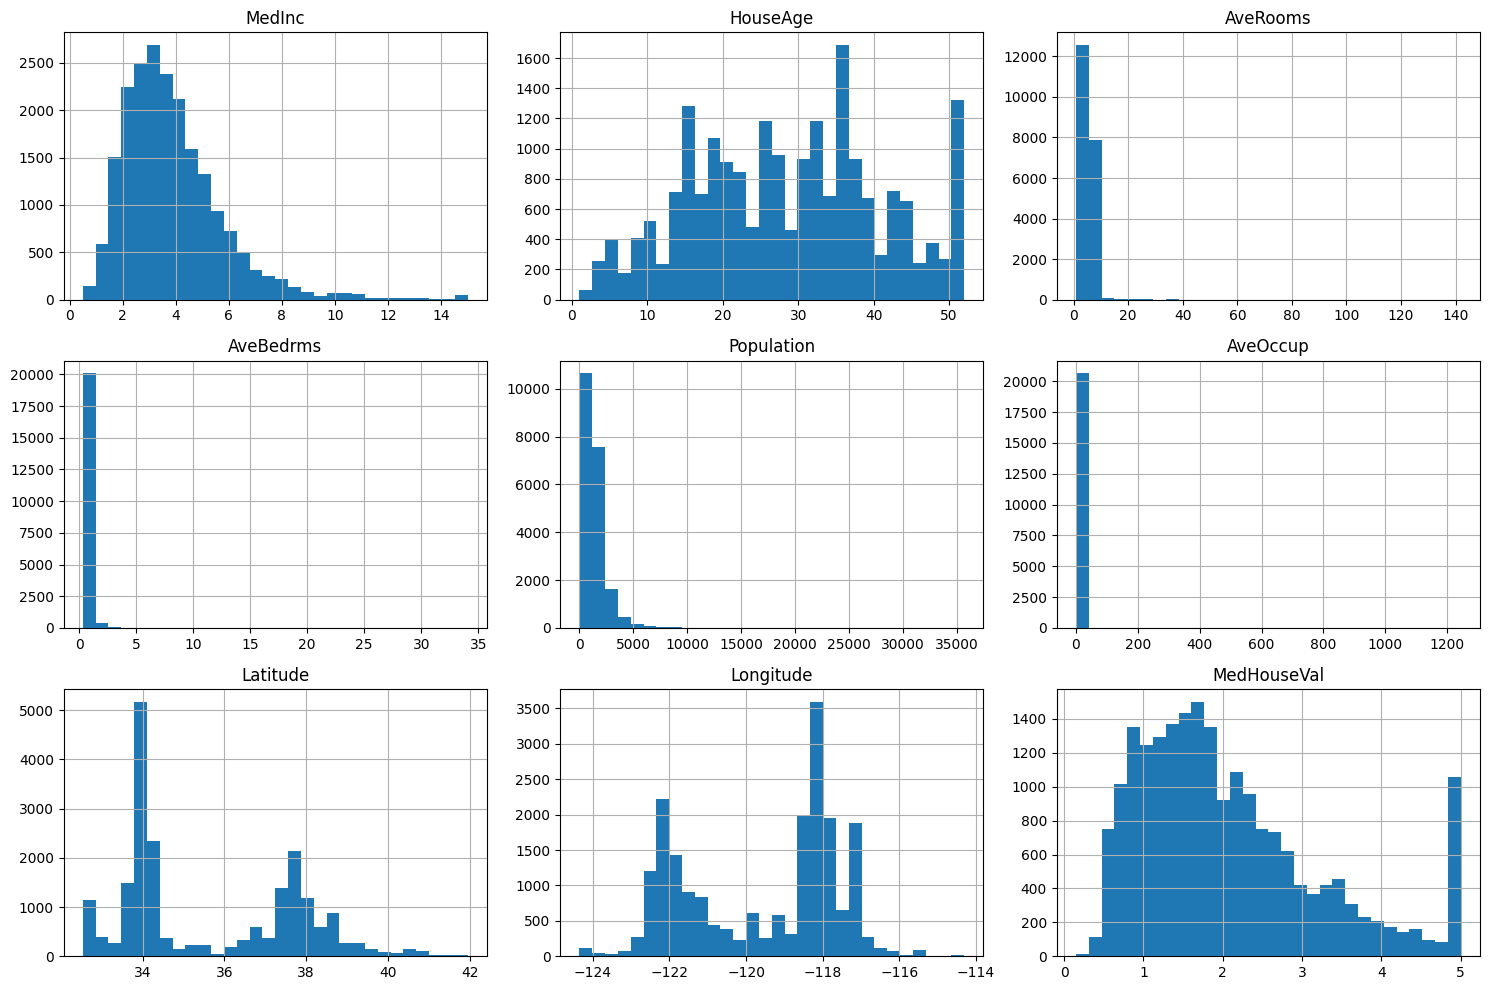

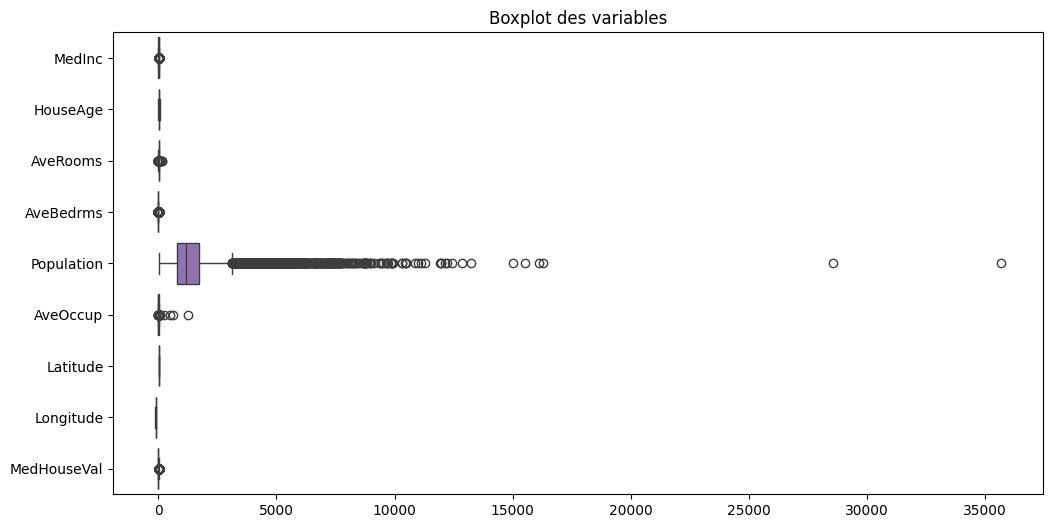

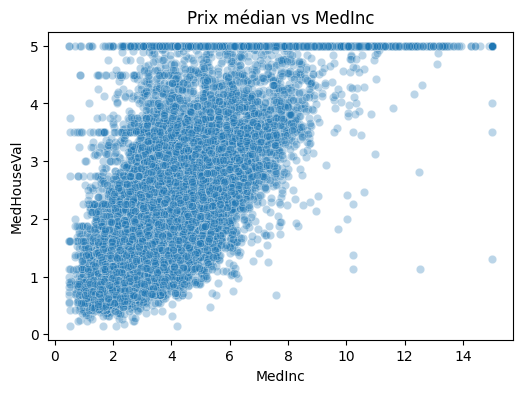

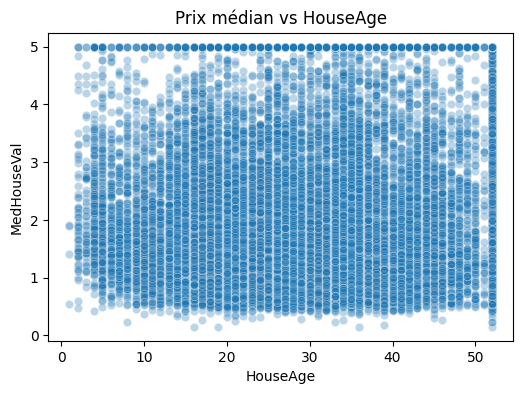

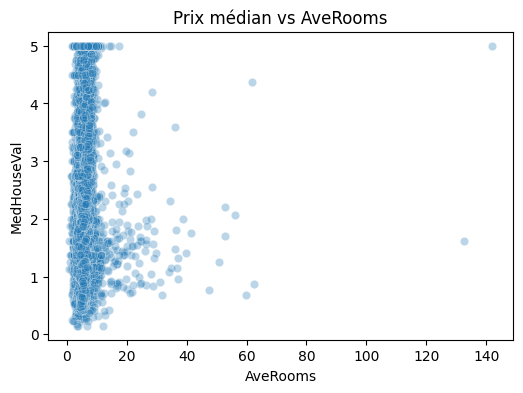

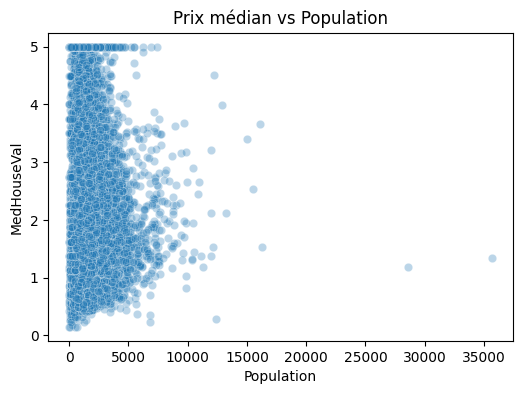

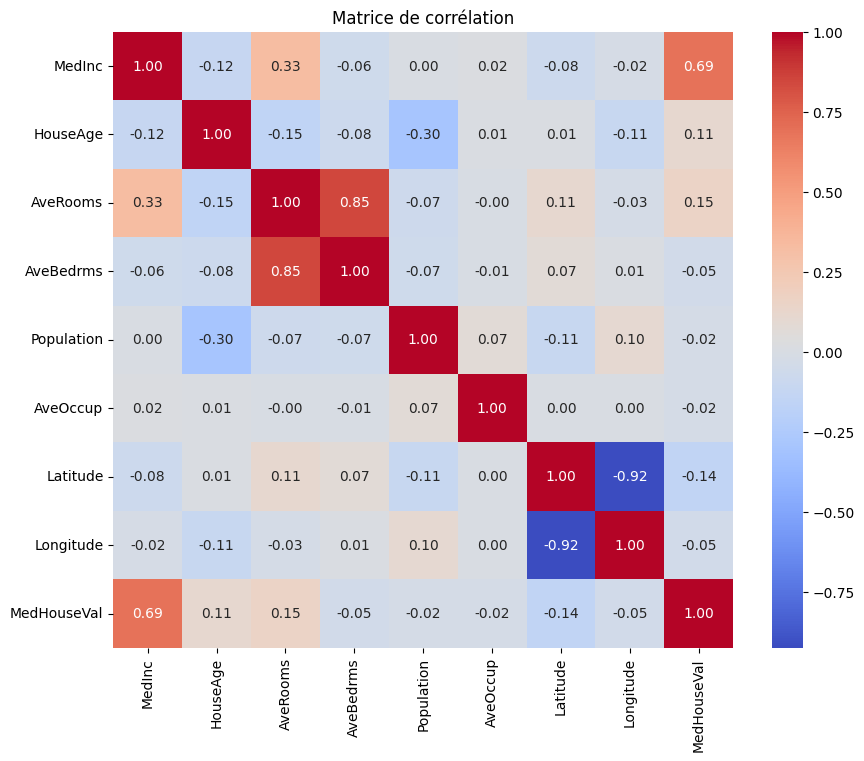

In [5]:
# 3. EDA: Statistiques descriptives, histogrammes, etc.

df.describe() #Statistiques descriptives

# histogramme
import matplotlib.pyplot as plt
df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()


# Boxplots (valeurs extrêmes)
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, orient='h')
plt.title("Boxplot des variables")
plt.show()

# Scatter plot: Prix vs variables clés
features = ['MedInc', 'HouseAge', 'AveRooms', 'Population']

for col in features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y="MedHouseVal", alpha=0.3)
    plt.title(f"Prix médian vs {col}")
    plt.show()


# matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()



In [6]:
# 4. Split train/validation/test

from sklearn.model_selection import train_test_split

# Variables explicatives (X) et cible (y)
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Étape 1 : Split train (60%) vs temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Étape 2 : Split temp en validation (20%) et test (20%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Vérification des tailles
print("Train set :", X_train.shape)
print("Validation set :", X_val.shape)
print("Test set :", X_test.shape)


Train set : (12384, 8)
Validation set : (4128, 8)
Test set : (4128, 8)


In [7]:
# 5. Feature engineering/selection

# Normalisation des variables (StandardScaler)
from sklearn.preprocessing import StandardScaler

# Initialisation du scaler
scaler = StandardScaler()

# Apprentissage sur le train, transformation sur train/val/test
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [8]:
# 6. Baseline: Regression linéaire

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Entraînement du modèle sur les données normalisées
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Prédictions sur le set de validation
y_pred_val = model.predict(X_val_scaled)

# Évaluation des performances
mse = mean_squared_error(y_val, y_pred_val)
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

# Affichage
print(f"📊 Performances du modèle de régression linéaire (Validation set):")
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")


📊 Performances du modèle de régression linéaire (Validation set):
MSE : 0.5326
MAE : 0.5336
R²  : 0.5920


In [9]:
# 7. Régularisation : Ridge : pénalisation L2 pour la multicolinéarité et Lasso : pénalisation L1 pour la sélection de features.
# Régression Ridge
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_val_scaled)

# Évaluation
mse_ridge = mean_squared_error(y_val, y_pred_ridge)
mae_ridge = mean_absolute_error(y_val, y_pred_ridge)
r2_ridge = r2_score(y_val, y_pred_ridge)

print("📌 Régression Ridge (alpha=1.0)")
print(f"MSE : {mse_ridge:.4f}")
print(f"MAE : {mae_ridge:.4f}")
print(f"R²  : {r2_ridge:.4f}")


📌 Régression Ridge (alpha=1.0)
MSE : 0.5326
MAE : 0.5336
R²  : 0.5920
